# Kronecker Eigendecomposition

For a Kronecker product $A \otimes B$, all eigenvalues and
eigenvectors decompose per-factor:

$$\lambda_{ij} = \lambda_i^A \cdot \lambda_j^B, \qquad
  v_{ij} = v_i^A \otimes v_j^B$$

This means we can compute the full spectrum of an $N \times N$
matrix ($N = n_1 n_2$) by only decomposing two small matrices.
gaussx exploits this for `cholesky`, `sqrt`, `logdet`, and `inv`.

## Context

The Kronecker eigendecomposition is a special case of the tensor
product spectral theorem. If $A = U_A \Lambda_A U_A^\top$ and
$B = U_B \Lambda_B U_B^\top$, then

$$A \otimes B
  = (U_A \otimes U_B)\,(\Lambda_A \otimes \Lambda_B)\,(U_A \otimes U_B)^\top.$$

This result is foundational for:

- **GP inference on grids** -- computing solves and log-determinants
  without forming the full $N \times N$ matrix (Saatci, 2012).
- **Solving Kronecker-structured linear systems** -- reducing an
  $N$-dimensional problem to two smaller per-factor problems.
- **Stochastic PDEs with separable operators** -- exploiting product
  structure in spatial and temporal discretizations.

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## Setup: PSD Kronecker product

In [2]:
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key)

n1, n2 = 8, 10
N = n1 * n2

# Random PSD matrices
M1 = jax.random.normal(k1, (n1, n1))
A = M1 @ M1.T + 0.1 * jnp.eye(n1)

M2 = jax.random.normal(k2, (n2, n2))
B = M2 @ M2.T + 0.1 * jnp.eye(n2)

A_op = lx.MatrixLinearOperator(A, lx.positive_semidefinite_tag)
B_op = lx.MatrixLinearOperator(B, lx.positive_semidefinite_tag)
K = gaussx.Kronecker(A_op, B_op)

print(f"A: {n1}x{n1}, B: {n2}x{n2}")
print(f"A kron B: {N}x{N} = {N**2:,} entries")

A: 8x8, B: 10x10
A kron B: 80x80 = 6,400 entries


## Per-factor eigenvalues

In [3]:
eigs_A = jnp.linalg.eigvalsh(A)
eigs_B = jnp.linalg.eigvalsh(B)

# Kronecker eigenvalues = outer product of per-factor eigenvalues
eigs_kron = jnp.sort(jnp.outer(eigs_A, eigs_B).ravel())

# Dense eigenvalues (for verification)
eigs_dense = jnp.linalg.eigvalsh(K.as_matrix())

print(f"Per-factor eigenvalues: {n1} + {n2} = {n1 + n2} eigh calls")
print(f"Dense eigenvalues: one {N}x{N} eigh call")
print(f"Max eigenvalue error: {jnp.max(jnp.abs(eigs_kron - eigs_dense)):.2e}")

Per-factor eigenvalues: 8 + 10 = 18 eigh calls
Dense eigenvalues: one 80x80 eigh call


Max eigenvalue error: 2.84e-13


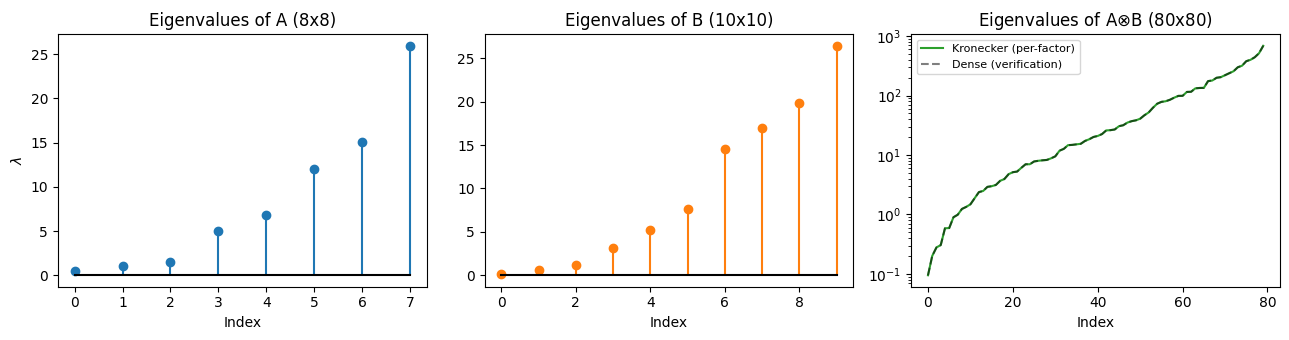

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].stem(range(n1), eigs_A, linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[0].set_title(f"Eigenvalues of A ({n1}x{n1})")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("$\\lambda$")

axes[1].stem(range(n2), eigs_B, linefmt="C1-", markerfmt="C1o", basefmt="k-")
axes[1].set_title(f"Eigenvalues of B ({n2}x{n2})")
axes[1].set_xlabel("Index")

axes[2].semilogy(eigs_kron, "C2-", label="Kronecker (per-factor)")
axes[2].semilogy(eigs_dense, "k--", alpha=0.5, label="Dense (verification)")
axes[2].set_title(f"Eigenvalues of A$\\otimes$B ({N}x{N})")
axes[2].set_xlabel("Index")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Structured Cholesky

`cholesky(A kron B) = cholesky(A) kron cholesky(B)`

In [5]:
L = gaussx.cholesky(K)
print(f"cholesky type: {type(L).__name__}")

# Reconstruction error
recon = L.as_matrix() @ L.as_matrix().T
print(f"||L L^T - K||_max: {jnp.max(jnp.abs(recon - K.as_matrix())):.2e}")

cholesky type: Kronecker


||L L^T - K||_max: 5.68e-14


## Structured sqrt

`sqrt(A kron B) = sqrt(A) kron sqrt(B)`

In [6]:
S = gaussx.sqrt(K)
print(f"sqrt type: {type(S).__name__}")

# Verify S @ S = K
recon_sqrt = S.as_matrix() @ S.as_matrix()
print(f"||S S - K||_max: {jnp.max(jnp.abs(recon_sqrt - K.as_matrix())):.2e}")

sqrt type: Kronecker
||S S - K||_max: 4.41e-13


## Structured logdet

$\log|A \otimes B| = n_2 \log|A| + n_1 \log|B|$

**Derivation.** Using the Kronecker eigenvalues
$\lambda_{ij} = \lambda_i^A \lambda_j^B$:

$$\log|A \otimes B|
  = \sum_{i,j} \log(\lambda_i^A \, \lambda_j^B)
  = \sum_{i,j} \bigl(\log \lambda_i^A + \log \lambda_j^B\bigr)
  = n_2 \sum_i \log \lambda_i^A + n_1 \sum_j \log \lambda_j^B
  = n_2 \log|A| + n_1 \log|B|.$$

In [7]:
ld_structured = gaussx.logdet(K)
ld_dense = jnp.linalg.slogdet(K.as_matrix())[1]
ld_from_eigs = jnp.sum(jnp.log(eigs_kron))

print(f"Structured logdet:  {ld_structured:.6f}")
print(f"Dense logdet:       {ld_dense:.6f}")
print(f"From eigenvalues:   {ld_from_eigs:.6f}")

Structured logdet:  233.876851
Dense logdet:       233.876851
From eigenvalues:   233.876851


## Summary

| Operation | Dense cost | Kronecker cost | Speedup |
|-----------|-----------|---------------|---------|
| Eigenvalues | O(N^3) | O(n1^3 + n2^3) | ~N/n_max |
| Cholesky | O(N^3) | O(n1^3 + n2^3) | ~N/n_max |
| Logdet | O(N^3) | O(n1^3 + n2^3) | ~N/n_max |
| Solve | O(N^3) | O(n1^3 + n2^3) | ~N/n_max |

## References

- Van Loan, C. F. (2000). The ubiquitous Kronecker product. *Journal
  of Computational and Applied Mathematics*, 123, 85--100.
- Saatci, Y. (2012). *Scalable Inference for Structured Gaussian
  Process Models*. PhD thesis, University of Cambridge.
- Steeb, W.-H. (2011). *Matrix Calculus and Kronecker Product*.
  2nd edition, World Scientific.